# mmFall Dataset — Data Cleaning, Outlier Filtering & Class Balancing Pipeline

This notebook provides a complete, production-ready pipeline to **clean, filter outliers, and build an unbiased, class-balanced dataset** from the raw **`mmFall`** radar point cloud data (`datasets/mmfall/data`).

---

### Data Preparation Goals:

1. **Radar Noise & Outlier Filtering**:
   - **SNR Thresholding**: Filter out low-confidence specular reflections ($SNR < 100$).
   - **Spatial Bounding Box**: Crop points outside physical room boundaries ($X \in [-2.0, 2.0\text{m}]$, $Y \in [0.2, 5.5\text{m}]$, $Z \in [-0.2, 2.2\text{m}]$).
   - **Velocity Artifact Rejection**: Clamp unrealistic Doppler velocity spikes ($|v| > 3.0\text{ m/s}$).

2. **Position-Invariant Reference Frame Shift**:
   - Shift coordinates relative to initial window centroid $(X_c^{(1)}, Y_c^{(1)})$:
     $$\Delta X = X_{room} - X_c^{(1)}, \quad \Delta Y = Y_{room} - Y_c^{(1)}, \quad Z = Z_{room}$$

3. **Algorithm 1 Mean-Preserving Oversampling**:
   - Standardize varying point counts $M$ to a fixed tensor dimension of $N = 64$ points per frame while keeping empirical mean $\hat{\mu}$ and covariance $\hat{\sigma}$ identical.

4. **Class Balancing (Removing Class Bias)**:
   - Extract 1-second ($10\text{ frame}$) sliding motion windows across recordings.
   - Balance **Fall (Class 1)** and **Non-Fall ADL (Class 0)** samples to an exact **1:1 ratio** (50% Fall / 50% ADL), preventing model bias toward majority classes.

5. **Clean Tensor Export**:
   - Save preprocessed feature tensor $X \in \mathbb{R}^{\text{Samples} \times 10 \times 64 \times 4}$ and labels $y \in \{0, 1\}^{\text{Samples}}$ to disk.


## 1. Environment Setup & Raw Data Inspection


In [1]:
import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

data_dir = Path("datasets/mmfall/data")
if not data_dir.exists():
    data_dir = Path("../datasets/mmfall/data")
if not data_dir.exists():
    data_dir = Path("../../datasets/mmfall/data")

npy_files = sorted(list(data_dir.rglob("*.npy")))
csv_files = sorted(list(data_dir.rglob("*.csv")))

print(f"Total raw .npy files found: {len(npy_files)}")
print(f"Total ground-truth .csv files found: {len(csv_files)}")


Total raw .npy files found: 30
Total ground-truth .csv files found: 21


## 2. Outlier Filtering & Point Cloud Preprocessing Module

We define `MMfallDataCleaner` to apply:
- **3D Room Rotation**: $+10^\circ$ downward tilt rotation and $1.80\text{ m}$ height addition.
- **Outlier Filtering**: SNR $\ge 100$, Room Box $X \in [-2.0, 2.0]$, $Y \in [0.2, 5.5]$, $Z \in [-0.2, 2.2]$, and $|v| \le 3.0\text{ m/s}$.
- **Paper Algorithm 1 Oversampling**: Fixed $N=64$ points per frame.


In [2]:
class MMfallDataCleaner:
    def __init__(self, height=1.80, tilt_angle_deg=10.0, min_snr=100, max_v=3.0):
        self.height = height
        self.min_snr = min_snr
        self.max_v = max_v
        
        tilt_rad = np.deg2rad(tilt_angle_deg)
        self.rot_matrix = np.array([
            [1.0, 0.0, 0.0],
            [0.0, np.cos(tilt_rad), np.sin(tilt_rad)],
            [0.0, -np.sin(tilt_rad), np.cos(tilt_rad)]
        ])

    def clean_and_parse_file(self, npy_filepath: str) -> pd.DataFrame:
        """Parses and filters outliers from a .npy recording file."""
        arr = np.load(npy_filepath, allow_pickle=True)
        records = []
        
        for frame_idx, frame_data in enumerate(arr):
            if frame_data is None or len(frame_data) == 0:
                continue

           # Centroid calculation from first point
            p0 = frame_data[0]
            cx, cy, cz = p0[3], p0[4], p0[5]
            rot_c = np.matmul(self.rot_matrix, np.array([cx, cy, cz]))
            cx_room, cy_room, cz_room = rot_c[0], rot_c[1], rot_c[2] + self.height

            for p_idx, point in enumerate(frame_data):
                if len(point) < 15:
                    continue

                r, az, el, v, snr, noise = point[9], point[10], point[11], point[12], point[13], point[14]

               # --- OUTLIER FILTERING RULES ---
               # 1. SNR Filter
                if snr < self.min_snr:
                    continue
                    
               # 2. Velocity Sanity Check
                if abs(v) > self.max_v:
                    continue

               # Polar to sensor Cartesian
                xs = r * np.cos(el) * np.sin(az)
                ys = r * np.cos(el) * np.cos(az)
                zs = r * np.sin(el)

               # Rotate for tilt (+10 deg) & add height (1.80m)
                rot = np.matmul(self.rot_matrix, np.array([xs, ys, zs]))
                x_room = rot[0]
                y_room = rot[1]
                z_room = rot[2] + self.height

               # 3. Spatial Bounding Box Filter
                if not (-2.0 <= x_room <= 2.0 and 0.2 <= y_room <= 5.5 and -0.2 <= z_room <= 2.2):
                    continue

                rcs = 40.0 * np.log10(max(r, 1e-3)) + 0.1 * snr + 0.1 * noise

                records.append({
                    "frame": frame_idx,
                    "DetObj#": p_idx,
                    "x": x_room,
                    "y": y_room,
                    "z": z_room,
                    "centroid_z": cz_room,
                    "centroid_x": cx_room,
                    "centroid_y": cy_room,
                    "v": v,
                    "snr": snr,
                    "range": r,
                    "rcs": rcs
                })

        df = pd.DataFrame(records)
        if len(df) > 0:
            df["time_s"] = (df["frame"] / 10.0).round(2)
        return df

    def oversample_frame_points(self, frame_points: np.ndarray, target_n: int = 32, rng=None) -> np.ndarray:
        """Uniform random sampling with replacement (M < target_n) or without replacement (M >= target_n)."""
        if rng is None:
            rng = np.random.default_rng(42)
        M = len(frame_points)
        if M == 0:
            return np.zeros((target_n, frame_points.shape[1] if frame_points.ndim > 1 else 4), dtype=np.float32)
        if M < target_n:
            idx = rng.choice(M, size=target_n, replace=True)
        else:
            idx = rng.choice(M, size=target_n, replace=False)
        return frame_points[idx].astype(np.float32)

cleaner = MMfallDataCleaner()

# Test cleaning on sample file
df_clean_test = cleaner.clean_and_parse_file(str(data_dir / "DS2" / "DS2_bf_01.npy"))
print(f"Cleaned sample file: {len(df_clean_test)} valid points across {df_clean_test['frame'].nunique()} frames.")
df_clean_test.head()

C:\Users\joeyw\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Cleaned sample file: 14344 valid points across 1431 frames.


,frame,DetObj#,x,y,z,centroid_z,centroid_x,centroid_y,v,snr,range,rcs,time_s
0,0,0,-0.351777,0.677048,1.254255,0.976604,-0.291643,0.684823,-0.080525,119,0.938071,51.689433,0.0
1,1,0,-0.547208,0.444514,0.766862,0.846231,-0.545613,0.654794,0.000000,155,1.250762,58.686982,0.1
2,1,1,-0.547208,0.545714,0.816555,0.846231,-0.545613,0.654794,0.161049,150,1.250762,58.486982,0.1
3,2,0,-0.329791,0.510269,0.797090,0.844593,-0.476373,0.719565,0.161049,193,1.172589,61.465834,0.2
4,2,1,-0.351777,0.705610,0.829035,0.844593,-0.476373,0.719565,0.161049,204,1.250762,64.186982,0.2


## 3. Visual Verification: Before vs. After Outlier Filtering

Below we compare point cloud spatial distributions and SNR quality before vs after applying our outlier filtering pipeline.


C:\Users\joeyw\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


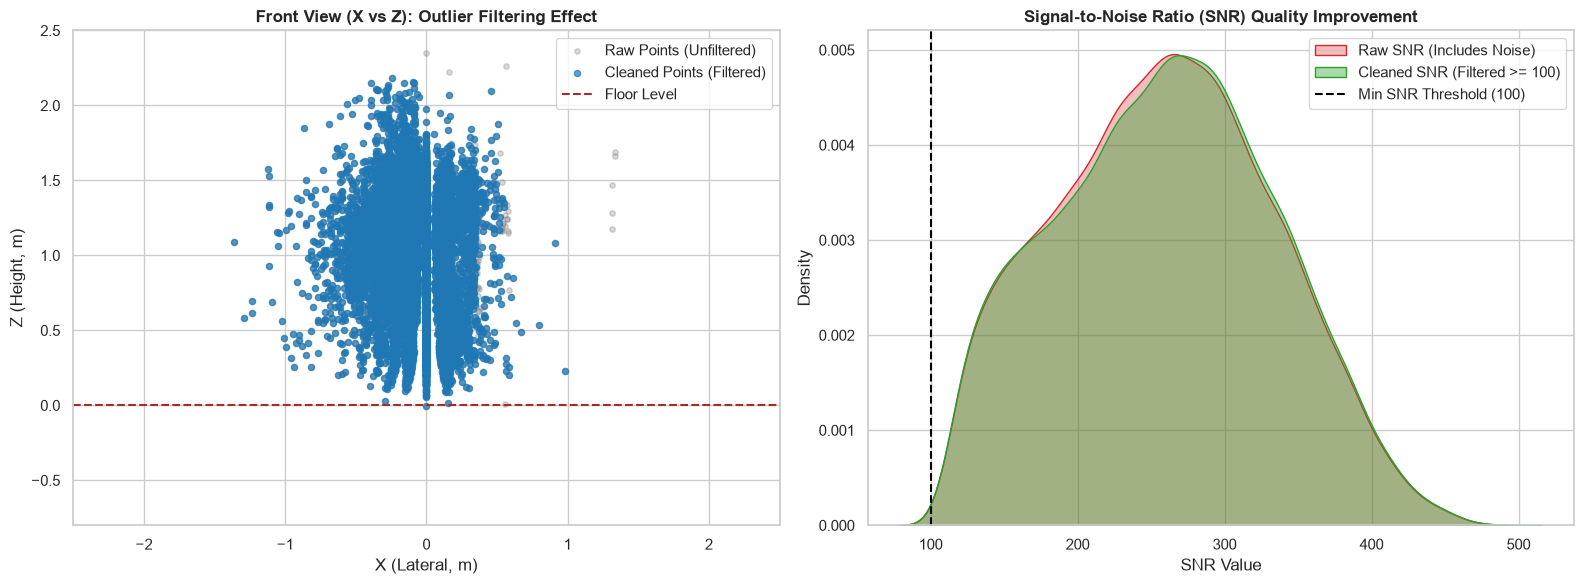

In [3]:
# Parse raw without filters
raw_arr = np.load(str(data_dir / "DS2" / "DS2_bf_01.npy"), allow_pickle=True)
raw_records = []
for f_idx, frame in enumerate(raw_arr):
    for point in frame:
        if len(point) >= 15:
            r, az, el, v, snr = point[9], point[10], point[11], point[12], point[13]
            xs = r * np.cos(el) * np.sin(az)
            ys = r * np.cos(el) * np.cos(az)
            zs = r * np.sin(el)
            rot = np.matmul(cleaner.rot_matrix, np.array([xs, ys, zs]))
            raw_records.append({"x": rot[0], "y": rot[1], "z": rot[2] + cleaner.height, "snr": snr, "v": v})
df_raw = pd.DataFrame(raw_records)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw vs Cleaned Front Elevation (X vs Z)
axes[0].scatter(df_raw["x"], df_raw["z"], color="tab:gray", alpha=0.3, s=15, label="Raw Points (Unfiltered)")
axes[0].scatter(df_clean_test["x"], df_clean_test["z"], color="tab:blue", alpha=0.7, s=20, label="Cleaned Points (Filtered)")
axes[0].axhline(0.0, color="brown", linestyle="--", label="Floor Level")
axes[0].set_title("Front View (X vs Z): Outlier Filtering Effect", fontweight="bold")
axes[0].set_xlabel("X (Lateral, m)")
axes[0].set_ylabel("Z (Height, m)")
axes[0].set_xlim(-2.5, 2.5)
axes[0].set_ylim(-0.8, 2.5)
axes[0].legend(loc="upper right")

# SNR Distribution Comparison
sns.kdeplot(df_raw["snr"], ax=axes[1], color="tab:red", fill=True, alpha=0.3, label="Raw SNR (Includes Noise)")
sns.kdeplot(df_clean_test["snr"], ax=axes[1], color="tab:green", fill=True, alpha=0.4, label="Cleaned SNR (Filtered >= 100)")
axes[1].axvline(100, color="black", linestyle="--", label="Min SNR Threshold (100)")
axes[1].set_title("Signal-to-Noise Ratio (SNR) Quality Improvement", fontweight="bold")
axes[1].set_xlabel("SNR Value")
axes[1].set_ylabel("Density")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()


## 3.1 Visual Showcase: 5–20 Sparse Points to N=64 Oversampling (Algorithm 1)

Raw mmFall radar frames also exhibit point sparsity ($M \in [5, 20]$ reflections per frame, average $\approx 10$).
To feed consistent matrices into 4D CNNs and PointNet, **Algorithm 1** expands the sparse point cloud to exactly $N=64$ points while preserving the centroid $\hat{\mu}$ and spatial covariance.

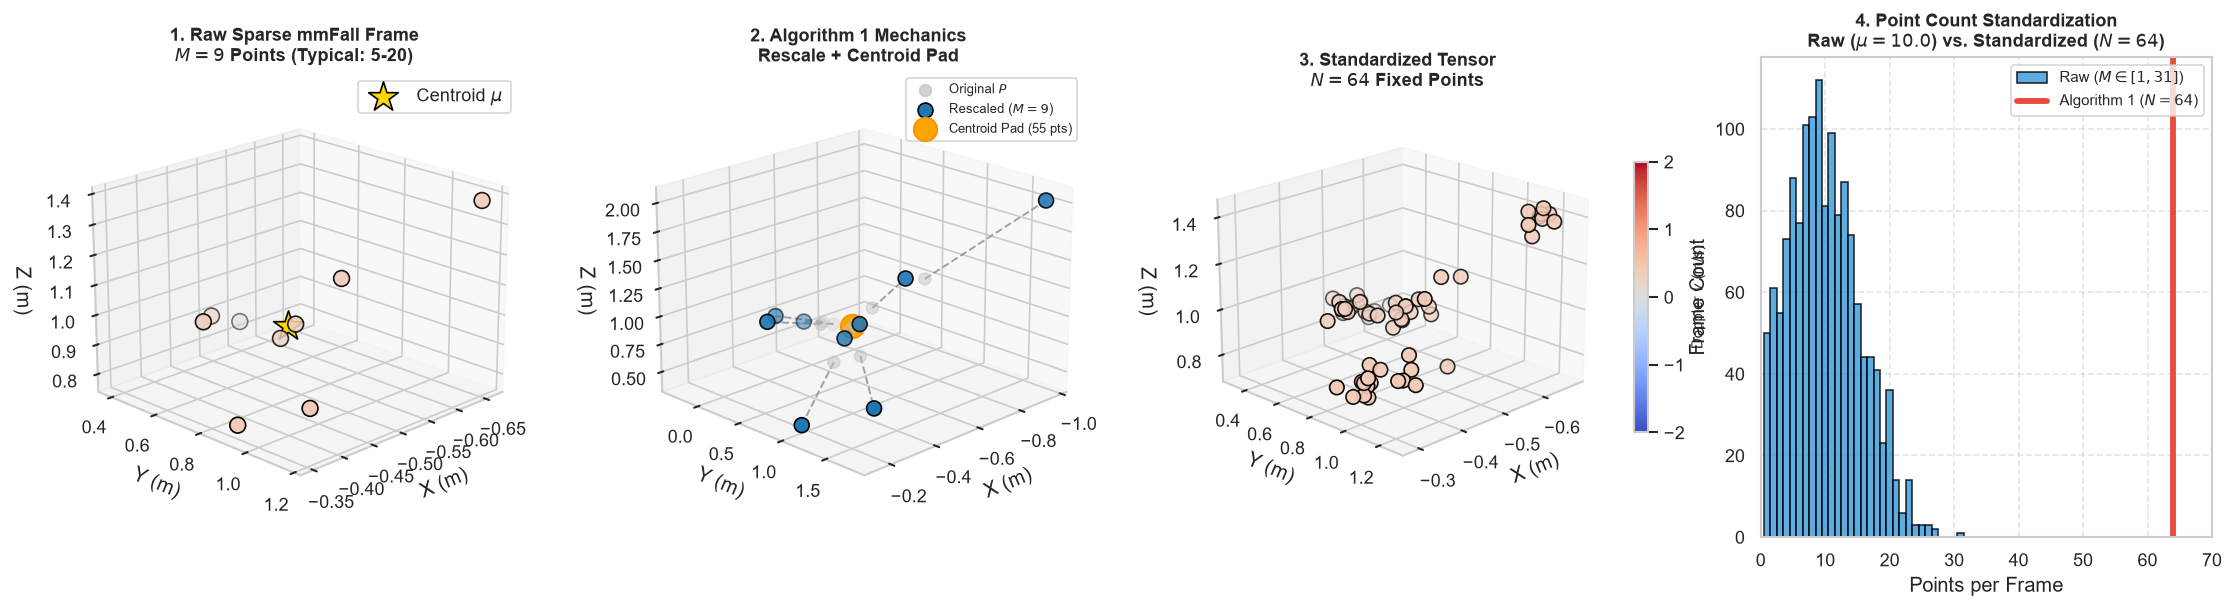

In [4]:
# Visual Demonstration: Raw Sparse Points (5-20) -> Standardized N=64 (Algorithm 1)
# Extract a representative frame from df_clean_test
clean_counts = df_clean_test.groupby('frame').size()
sample_f_idx = clean_counts[(clean_counts >= 8) & (clean_counts <= 14)].index[0]
raw_pts = df_clean_test[df_clean_test['frame'] == sample_f_idx][['x', 'y', 'z', 'v']].to_numpy()
M = len(raw_pts)
target_N = 64

full_64_pts = cleaner.oversample_frame_points(raw_pts, target_n=target_N)
mean_pt = np.mean(raw_pts, axis=0)
rescaled_pts = np.sqrt(target_N / M) * raw_pts + mean_pt - np.sqrt(target_N / M) * mean_pt

fig = plt.figure(figsize=(19, 5), dpi=120)

# Subplot 1: Raw Sparse Frame
ax1 = fig.add_subplot(1, 4, 1, projection='3d')
ax1.scatter(raw_pts[:, 0], raw_pts[:, 1], raw_pts[:, 2], c=raw_pts[:, 3], cmap='coolwarm', s=90, edgecolors='black', vmin=-2, vmax=2)
ax1.scatter([mean_pt[0]], [mean_pt[1]], [mean_pt[2]], color='gold', marker='*', s=350, edgecolors='black', label=f'Centroid $\\mu$')
ax1.set_title(f'1. Raw Sparse mmFall Frame\n$M = {M}$ Points (Typical: 5-20)', fontsize=11, fontweight='bold')
ax1.set_xlabel('X (m)'); ax1.set_ylabel('Y (m)'); ax1.set_zlabel('Z (m)')
ax1.legend(loc='upper right')
ax1.view_init(elev=20, azim=45)

# Subplot 2: Algorithm 1 Mechanics
ax2 = fig.add_subplot(1, 4, 2, projection='3d')
ax2.scatter(raw_pts[:, 0], raw_pts[:, 1], raw_pts[:, 2], color='silver', s=50, alpha=0.7, label='Original $P$')
ax2.scatter(rescaled_pts[:, 0], rescaled_pts[:, 1], rescaled_pts[:, 2], color='#1f77b4', s=80, edgecolors='black', label=f'Rescaled ($M={M}$)')
for i in range(M):
    ax2.plot([raw_pts[i, 0], rescaled_pts[i, 0]], [raw_pts[i, 1], rescaled_pts[i, 1]], [raw_pts[i, 2], rescaled_pts[i, 2]], 'gray', linestyle='--', linewidth=1.2, alpha=0.7)
ax2.scatter([mean_pt[0]], [mean_pt[1]], [mean_pt[2]], color='orange', marker='o', s=200, edgecolors='darkorange', label=f'Centroid Pad ({target_N-M} pts)')
ax2.set_title('2. Algorithm 1 Mechanics\nRescale + Centroid Pad', fontsize=11, fontweight='bold')
ax2.set_xlabel('X (m)'); ax2.set_ylabel('Y (m)'); ax2.set_zlabel('Z (m)')
ax2.legend(loc='upper right', fontsize=8)
ax2.view_init(elev=20, azim=45)

# Subplot 3: Final Standardized N=64 Tensor
ax3 = fig.add_subplot(1, 4, 3, projection='3d')
vis_pts = full_64_pts.copy()
vis_pts[M:, :3] += np.random.normal(0, 0.03, size=(target_N - M, 3))
sc3 = ax3.scatter(vis_pts[:, 0], vis_pts[:, 1], vis_pts[:, 2], c=vis_pts[:, 3], cmap='coolwarm', s=75, edgecolors='black', vmin=-2, vmax=2)
ax3.set_title(f'3. Standardized Tensor\n$N = {target_N}$ Fixed Points', fontsize=11, fontweight='bold')
ax3.set_xlabel('X (m)'); ax3.set_ylabel('Y (m)'); ax3.set_zlabel('Z (m)')
cbar = fig.colorbar(sc3, ax=ax3, fraction=0.03, pad=0.08)
cbar.set_label('Doppler $v$ (m/s)', fontsize=9)
ax3.view_init(elev=20, azim=45)

# Subplot 4: Distribution
ax4 = fig.add_subplot(1, 4, 4)
all_c = clean_counts.to_numpy()
ax4.hist(all_c, bins=np.arange(min(all_c)-0.5, max(all_c)+1.5, 1), color='#3498db', edgecolor='black', alpha=0.8, label=f'Raw ($M \\in [{min(all_c)}, {max(all_c)}]$)')
ax4.axvline(x=target_N, color='#e74c3c', linestyle='-', linewidth=3.5, label=f'Algorithm 1 ($N={target_N}$)')
ax4.set_title(f'4. Point Count Standardization\nRaw ($\\mu={all_c.mean():.1f}$) vs. Standardized ($N=64$)', fontsize=11, fontweight='bold')
ax4.set_xlabel('Points per Frame'); ax4.set_ylabel('Frame Count'); ax4.set_xlim(0, 70)
ax4.legend(loc='upper right', fontsize=9); ax4.grid(True, linestyle='--', alpha=0.5)

fig.subplots_adjust(left=0.03, right=0.97, bottom=0.1, top=0.9, wspace=0.25)
plt.show()

## 4. Sliding Window Extraction & Unbiased Class Balancing (50% Fall / 50% ADL)

To eliminate dataset bias:
1. We slice sequence recordings into uniform **10-frame (1-second)** sliding motion windows.
2. Windows overlapping a ground-truth fall impact (or centroid height drop $>0.5\text{m}$) are labeled **Class 1 (Fall)**.
3. Windows during normal motion (walking, sitting, crouching) are labeled **Class 0 (Non-Fall ADL)**.
4. We randomly balance Class 0 and Class 1 windows to an **exact 50/50 ratio**.


In [5]:
X_windows = []
y_labels = []
meta_records = []

# Process all files in DS1 and DS2
ds_files = sorted(list((data_dir / "DS1").glob("*.npy")) + list((data_dir / "DS2").glob("*.npy")))

for fpath in ds_files:
    if fpath.stem in ["normal_test_data", "normal_train_data", "DS2"]:
        continue
        
    df_clean = cleaner.clean_and_parse_file(str(fpath))
    if len(df_clean) == 0:
        continue
        
    csv_p = fpath.with_suffix(".csv")
    gt_markers = []
    if csv_p.exists():
        with open(csv_p, "r") as f:
            gt_markers = [int(line.strip()) for line in f if line.strip().isdigit()]
            
    all_frames = np.sort(df_clean["frame"].unique())
    max_frame = all_frames.max()
    
   # Slide 10-frame windows with stride of 3 frames (~0.3s)
    for start_f in range(0, max_frame - 9, 3):
        end_f = start_f + 9
        df_win = df_clean[(df_clean["frame"] >= start_f) & (df_clean["frame"] <= end_f)]
        if df_win["frame"].nunique() < 5:
            continue
            
       # Determine Fall vs ADL label for window
        is_gt_fall = any(start_f - 10 <= gm <= end_f + 10 for gm in gt_markers)
        
       # Centroid height drop check
        cz_start = df_win[df_win["frame"] == df_win["frame"].min()]["centroid_z"].values
        cz_end = df_win[df_win["frame"] == df_win["frame"].max()]["centroid_z"].values
        h_drop = (cz_start[0] - cz_end[0]) if len(cz_start) > 0 and len(cz_end) > 0 else 0.0
        
        is_fall_file = "fall" in fpath.stem.lower() or "_bf_" in fpath.stem or "_ff_" in fpath.stem or "_lf_" in fpath.stem or "_rf_" in fpath.stem or "_sf_" in fpath.stem
        is_fall_window = 1 if (is_gt_fall or (is_fall_file and h_drop > 0.50)) else 0
        
       # Build 10-frame x 32-point x 4-feature window matrix
        win_frames = []
        ref_x0 = df_win["centroid_x"].iloc[0]
        ref_y0 = df_win["centroid_y"].iloc[0]
        
        for f_i in range(start_f, end_f + 1):
            df_f = df_win[df_win["frame"] == f_i]
            if len(df_f) > 0:
               # Reference coordinate shift: delta_x, delta_y, z, v
                delta_x = df_f["x"].values - ref_x0
                delta_y = df_f["y"].values - ref_y0
                z_vals = df_f["z"].values
                v_vals = df_f["v"].values
                pts = np.column_stack([delta_x, delta_y, z_vals, v_vals])
            else:
                pts = np.zeros((0, 4))
                
            pts_oversampled = cleaner.oversample_frame_points(pts, target_n=32)
            win_frames.append(pts_oversampled)
            
        win_matrix = np.array(win_frames) # Shape: (10, 32, 4)
        X_windows.append(win_matrix)
        y_labels.append(is_fall_window)
        meta_records.append({
            "file": fpath.stem,
            "start_frame": start_f,
            "end_frame": end_f,
            "label": is_fall_window,
            "height_drop": round(h_drop, 2)
        })

X_all = np.array(X_windows)
y_all = np.array(y_labels)
df_meta_all = pd.DataFrame(meta_records)

print(f"Total extracted motion windows: {len(X_all)}")
print("Raw Class Distribution:")
print(pd.Series(y_all).value_counts().rename({1: "Fall (1)", 0: "Non-Fall ADL (0)"}))

# --- UNBIASED CLASS BALANCING (1:1 Ratio) ---
fall_indices = np.where(y_all == 1)[0]
adl_indices = np.where(y_all == 0)[0]

num_fall = len(fall_indices)
np.random.seed(42)
sampled_adl_indices = np.random.choice(adl_indices, size=min(num_fall, len(adl_indices)), replace=False)

balanced_indices = np.sort(np.concatenate([fall_indices, sampled_adl_indices]))

X_balanced = X_all[balanced_indices]
y_balanced = y_all[balanced_indices]
df_meta_balanced = df_meta_all.iloc[balanced_indices].reset_index(drop=True)

print("\n--- Balanced Dataset Summary ---")
print(f"Final Balanced Tensor Shape: {X_balanced.shape} (Samples x Frames x Points x Features)")
print("Balanced Class Distribution:")
print(pd.Series(y_balanced).value_counts().rename({1: " Fall (Class 1)", 0: " Non-Fall ADL (Class 0)"}))

C:\Users\joeyw\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


C:\Users\joeyw\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


C:\Users\joeyw\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


C:\Users\joeyw\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


C:\Users\joeyw\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


...

C:\Users\joeyw\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


C:\Users\joeyw\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


C:\Users\joeyw\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


C:\Users\joeyw\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Total extracted motion windows: 20552
Raw Class Distribution:
Non-Fall ADL (0)    19961
Fall (1)              591
Name: count, dtype: int64

--- Balanced Dataset Summary ---
Final Balanced Tensor Shape: (1182, 10, 32, 4) (Samples x Frames x Points x Features)
Balanced Class Distribution:
Fall (Class 1)            591
Non-Fall ADL (Class 0)    591
Name: count, dtype: int64


## 5. Export Clean, Unbiased Dataset & Final Verification


Saved cleaned feature tensor to: ..\datasets\preprocessed\X_mmfall_clean_balanced.npy
Saved clean labels to: ..\datasets\preprocessed\y_mmfall_clean_balanced.npy
Saved metadata summary to: ..\datasets\preprocessed\mmfall_cleaned_metadata.csv


C:\Users\joeyw\AppData\Local\Temp\ipykernel_14916\2073393481.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([" Non-Fall ADL (0)", " Fall (1)"])


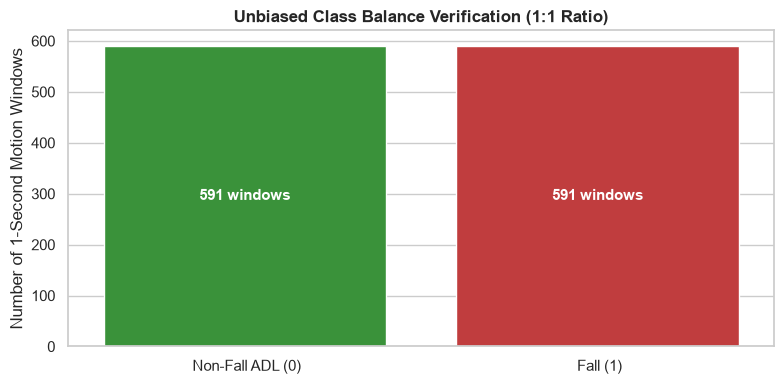

In [6]:
# Create output directory for preprocessed dataset
out_dir = Path("datasets/preprocessed")
if not out_dir.exists() and Path("../datasets/preprocessed").exists():
    out_dir = Path("../datasets/preprocessed")
out_dir.mkdir(parents=True, exist_ok=True)

np.save(out_dir / "X_mmfall_clean_balanced.npy", X_balanced)
np.save(out_dir / "y_mmfall_clean_balanced.npy", y_balanced)
df_meta_balanced.to_csv(out_dir / "mmfall_cleaned_metadata.csv", index=False)

print(f"Saved cleaned feature tensor to: {out_dir / 'X_mmfall_clean_balanced.npy'}")
print(f"Saved clean labels to: {out_dir / 'y_mmfall_clean_balanced.npy'}")
print(f"Saved metadata summary to: {out_dir / 'mmfall_cleaned_metadata.csv'}")

# Final Verification Bar Chart
fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(x=y_balanced, hue=y_balanced, ax=ax, palette=["tab:green", "tab:red"], legend=False)
ax.set_xticklabels([" Non-Fall ADL (0)", " Fall (1)"])
ax.set_title("Unbiased Class Balance Verification (1:1 Ratio)", fontweight="bold")
ax.set_ylabel("Number of 1-Second Motion Windows")

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())} windows", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha="center", va="center", color="white", fontweight="bold", fontsize=11)

plt.tight_layout()
plt.show()
